In [1]:
import tensorflow as tf

from load_data import load_datasets
from helper_functions import eval_model,display_samples
%matplotlib inline

2024-03-29 07:22:57.051931: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-29 07:22:57.051979: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-29 07:22:57.052980: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-29 07:22:57.058556: I tensorflow/core/platform/cpu_feature_guard.cc:183] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/root/.local/lib/python3.10/site-packag

In [2]:
image_size=256
batch_size=16
dataset_path='130kv2/'

2024-03-29 07:22:59.730827: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-29 07:22:59.736518: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-29 07:22:59.736555: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-29 07:22:59.740845: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-29 07:22:59.740924: I external/local_xla/xla/stream_executor

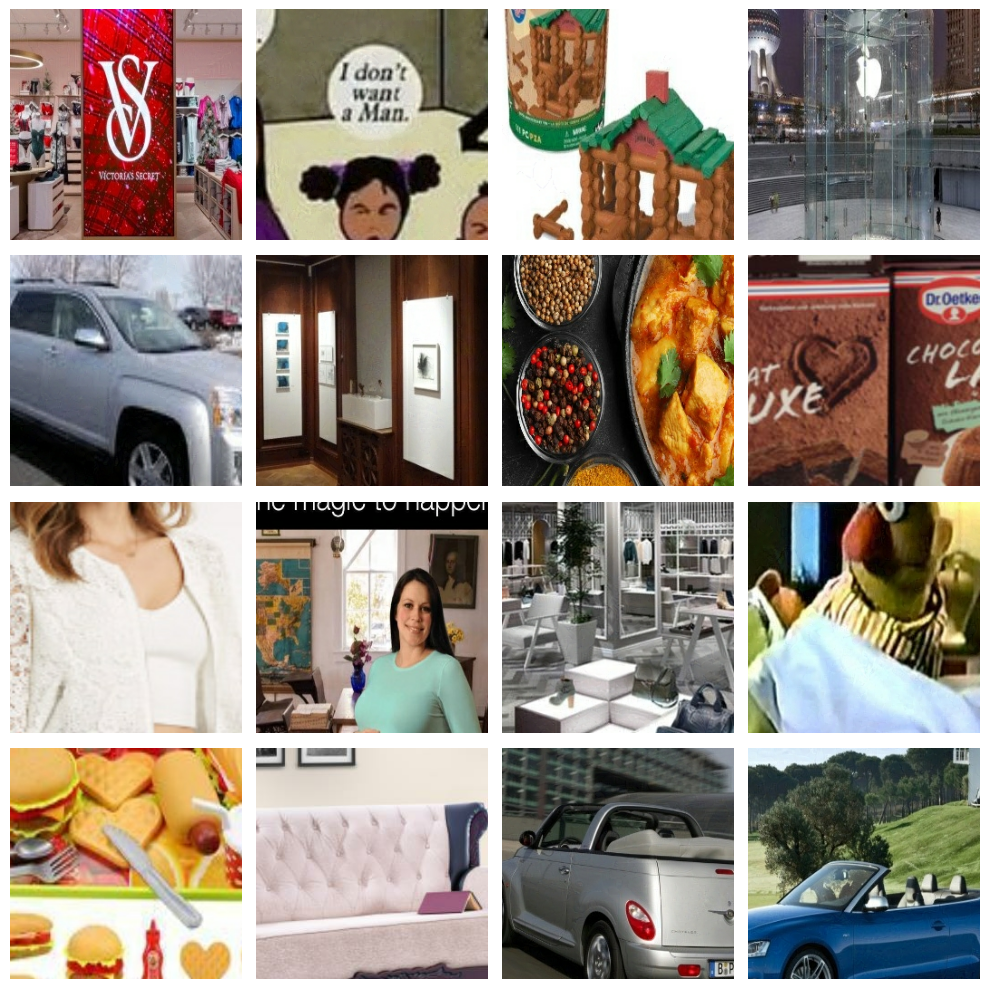

Train dataset: 
tf.Tensor(6160, shape=(), dtype=int64)

Validation dataset: 
tf.Tensor(1320, shape=(), dtype=int64)

Test dataset: 
tf.Tensor(1320, shape=(), dtype=int64)


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>

In [3]:
# load our training, validation and test datasets
train_ds, val_ds, test_ds = load_datasets(dataset_path, image_size, batch_size)

# display 10 samples to make sure they loaded OK
display_samples(train_ds)

# and check how many we have in each dataset
print('Train dataset: ')
print(train_ds.cardinality())
print('\nValidation dataset: ')
print(val_ds.cardinality())
print('\nTest dataset: ')
print(test_ds.cardinality())

# lastly batch them up and cache them
train_ds = train_ds.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

train_ds

In [4]:
# add some minor augmentation, avoiding anything which might rescale or otherwise impact perturbations
# see https://keras.io/examples/vision/image_classification_from_scratch/
data_augmentation_layers = tf.keras.Sequential([
    #tf.keras.layers.Normalization(),
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.05),
])

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

In [5]:
def make_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    # Entry block
    x = data_augmentation_layers(inputs)
    x = tf.keras.layers.Rescaling(1.0 / 255)(x) # might want to comment this out if we do it in pre
    x = tf.keras.layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual

    for size in [256, 512]:
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.SeparableConv2D(size, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization()(x)

        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.SeparableConv2D(size, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization()(x)

        x = tf.keras.layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = tf.keras.layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = tf.keras.layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    x = tf.keras.layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    if num_classes == 2:
        units = 1
    else:
        units = num_classes

    x = tf.keras.layers.Dropout(0.25)(x)
    # We specify activation=None so as to return logits
    outputs = tf.keras.layers.Dense(units, activation=None)(x)
    return tf.keras.Model(inputs, outputs)

model = make_model(input_shape=(image_size,image_size) + (3,), num_classes=2)
#tf.keras.utils.plot_model(model, 'models/model.png', show_shapes=True, rankdir='TB')

In [7]:
epochs = 10

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("models/save_at_{epoch}.keras"),
]
model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy")],
)
model_history = model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds,
).history

Epoch 1/10


2024-03-29 07:23:05.961392: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:467] Loaded cuDNN version 90000
2024-03-29 07:23:08.097347: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f0cd0bf8c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-03-29 07:23:08.097386: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2024-03-29 07:23:08.103210: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1711696988.172529   64887 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


385/385 [==============================] - 49s 103ms/step - loss: 0.7403 - accuracy: 0.5023 - val_loss: 0.7138 - val_accuracy: 0.5000
Epoch 2/10
385/385 [==============================] - 25s 66ms/step - loss: 0.7183 - accuracy: 0.5028 - val_loss: 0.8121 - val_accuracy: 0.4955
Epoch 3/10
385/385 [==============================] - 25s 66ms/step - loss: 0.7067 - accuracy: 0.5028 - val_loss: 0.9280 - val_accuracy: 0.5000
Epoch 4/10
385/385 [==============================] - 26s 66ms/step - loss: 0.6931 - accuracy: 0.5157 - val_loss: 1.9435 - val_accuracy: 0.5000
Epoch 5/10
385/385 [==============================] - 25s 66ms/step - loss: 0.6304 - accuracy: 0.6141 - val_loss: 2.4458 - val_accuracy: 0.5144
Epoch 6/10
385/385 [==============================] - 26s 66ms/step - loss: 0.4690 - accuracy: 0.7640 - val_loss: 1.4483 - val_accuracy: 0.6273
Epoch 7/10
385/385 [==============================] - 25s 66ms/step - loss: 0.3560 - accuracy: 0.8356 - val_loss: 2.0273 - val_accuracy: 0.6114
Ep


initial_model training history


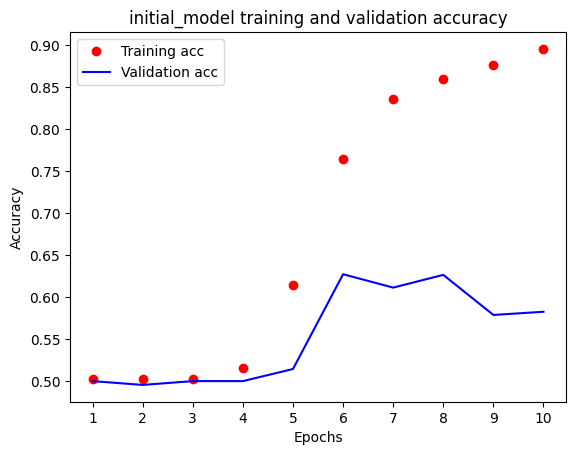

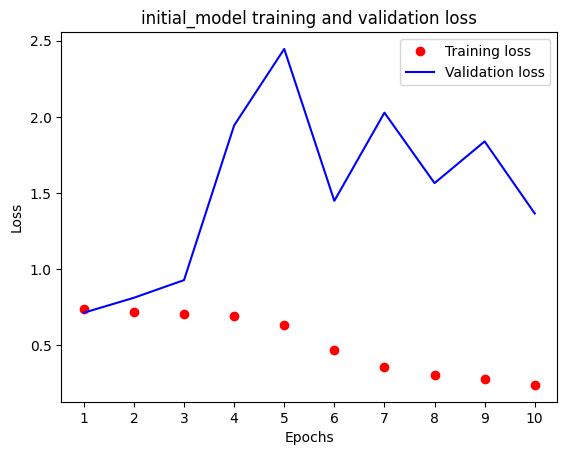

initial_model summary
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 sequential (Sequential)     (None, None, None, 3)        0         ['input_1[0][0]']             
                                                                                                  
 rescaling (Rescaling)       (None, 256, 256, 3)          0         ['sequential[0][0]']          
                                                                                                  
 conv2d (Conv2D)             (None, 128, 128, 128)        3584      ['rescaling[0][0]']           
                                                                        

In [8]:
#model = tf.keras.models.load_model('save_at_3.keras')
eval_results = eval_model('initial_model',model,model_history,val_ds,test_ds)
#model_history